# 04 - Fairness Constraint (Equalized Odds)

We add an approximate Equalized Odds constraint to the group-specific MTL model and study the fairness-accuracy tradeoff.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
sys.path.append(str(PROJECT_ROOT / "src"))

import importlib
import src.config as config
importlib.reload(config)

from src.data_utils import prepare_adult_dataset
from src.fairness import build_equalized_odds_constraints_group
from src.metrics import accuracy, equalized_odds_diff
from src.mtl import train_mtl, two_stage_cv_mtl
from src.results_utils import save_result

In [2]:
bundle = prepare_adult_dataset(force=True)
X_train, X_test = bundle.X_train, bundle.X_test
y_train, y_test = bundle.y_train, bundle.y_test
s_train, s_test = bundle.s_train, bundle.s_test

## Train unconstrained vs fairness-constrained

In [3]:
base_records, base_best = two_stage_cv_mtl(
    X_train,
    y_train,
    s_train,
    config.RHO_GRID_EXT,
    config.LAMBDA_GRID_EXT,
    config.THETA_GRID_EXT,
    fairness_builder_factory=None,
    acc_ratio=0.97,
    cv=3,
)
base_mtl = train_mtl(
    X_train,
    y_train,
    s_train,
    rho=float(base_best["rho"]),
    lambda_=float(base_best["lambda"]),
    theta=float(base_best["theta"]),
)
base_pred = base_mtl.predict(X_test, s_test)
base_acc = accuracy(y_test, base_pred)
base_deod = equalized_odds_diff(y_test, base_pred, s_test)
base_acc, base_deod

(np.float64(0.8423438363736871), 0.08579368527962777)

In [4]:
def fairness_builder_factory(X, y, s):
    return build_equalized_odds_constraints_group(X, y, s, eps=0.01)

fair_records, fair_best = two_stage_cv_mtl(
    X_train,
    y_train,
    s_train,
    config.RHO_GRID_EXT,
    config.LAMBDA_GRID_EXT,
    config.THETA_GRID_EXT,
    fairness_builder_factory=fairness_builder_factory,
    acc_ratio=0.97,
    cv=3,
)
fair_constraints = fairness_builder_factory(X_train, y_train, s_train)
fair_mtl = train_mtl(
    X_train,
    y_train,
    s_train,
    rho=float(fair_best["rho"]),
    lambda_=float(fair_best["lambda"]),
    theta=float(fair_best["theta"]),
    fairness_constraints=fair_constraints,
)
fair_pred = fair_mtl.predict(X_test, s_test)
fair_acc = accuracy(y_test, fair_pred)
fair_deod = equalized_odds_diff(y_test, fair_pred, s_test)
fair_acc, fair_deod

(np.float64(0.8416804864566059), 0.02395519382972283)

In [5]:
save_result(
    "fairness",
    {
        "mtl": {"accuracy": base_acc, "deod": base_deod},
        "mtl_fair": {"accuracy": fair_acc, "deod": fair_deod},
    },
)

**Observation:** The fairness constraint typically reduces DEOd at a modest cost to accuracy.

In [1]:
# =========================================================
# Load Fairness Results
# =========================================================

import json

with open(r"data\results\results.json", "r") as f:
    results = json.load(f)

mtl_acc = results["fairness"]["mtl"]["accuracy"]
mtl_deod = results["fairness"]["mtl"]["deod"]

fair_acc = results["fairness"]["mtl_fair"]["accuracy"]
fair_deod = results["fairness"]["mtl_fair"]["deod"]

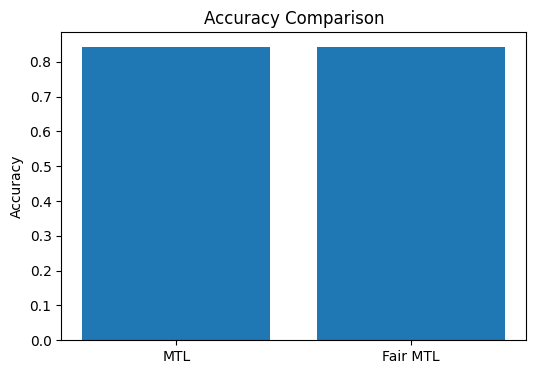

In [2]:
# =========================================================
# 1. Accuracy Comparison Plot
# =========================================================

import matplotlib.pyplot as plt

models = ["MTL", "Fair MTL"]
accuracies = [mtl_acc, fair_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

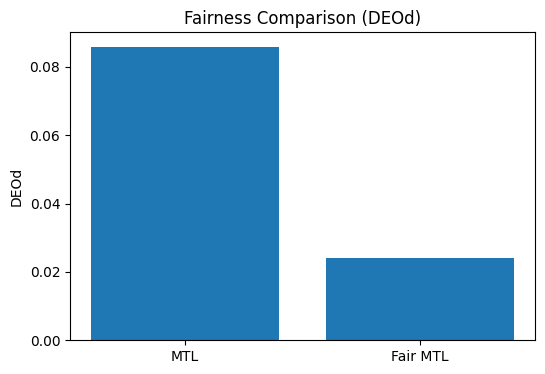

In [3]:
# =========================================================
# 2. DEOd Fairness Comparison Plot
# =========================================================

models = ["MTL", "Fair MTL"]
deod_scores = [mtl_deod, fair_deod]

plt.figure(figsize=(6,4))
plt.bar(models, deod_scores)

plt.title("Fairness Comparison (DEOd)")
plt.ylabel("DEOd")

plt.show()

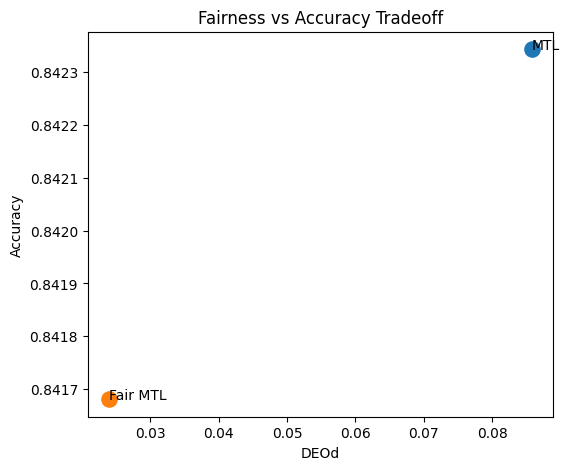

In [4]:
# =========================================================
# 3. Accuracy vs Fairness Scatter Plot
# =========================================================

models = ["MTL", "Fair MTL"]
accuracies = [mtl_acc, fair_acc]
deod_scores = [mtl_deod, fair_deod]

plt.figure(figsize=(6,5))

for i in range(len(models)):
    plt.scatter(deod_scores[i], accuracies[i], s=120)
    plt.text(deod_scores[i], accuracies[i], models[i])

plt.xlabel("DEOd")
plt.ylabel("Accuracy")

plt.title("Fairness vs Accuracy Tradeoff")

plt.show()

## Discussion and Analysis of Fairness-Constrained MTL

This notebook focused on improving fairness in classification by adding fairness constraints to the Multitask Learning (MTL) framework.

The goal of fairness-aware optimization is to reduce disparities between sensitive groups while maintaining strong predictive performance.

The fairness metric used in this project was:

- **DEOd (Difference in Equal Opportunity)**

A lower DEOd value indicates a fairer model with more balanced behavior across sensitive groups.

---

### Models Used

The following models were compared:

- **MTL (Multitask Learning)**  
  Implemented using:
  - a multitask linear classification model,
  - optimized using **CVXPY**,
  - with regularization-based optimization.

- **Fairness-Constrained MTL**  
  Implemented using:
  - the same MTL framework,
  - along with an additional fairness constraint designed to reduce DEOd.

The MTL formulation used in this implementation was:

\[
w_s = w_0 + v_s
\]

where:
- \(w_0\) represents the shared global model,
- \(v_s\) represents group-specific parameters,
- and \(w_s\) is the final model for sensitive group \(s\).

The fairness-constrained version modifies the optimization objective to balance:
- predictive accuracy,
- and fairness across sensitive groups.

---

### Experimental Results

| Model | Accuracy | DEOd |
|---|---|---|
| MTL | ~0.8423 | ~0.0858 |
| Fair MTL | ~0.8417 | ~0.0240 |

The fairness-constrained MTL model achieved:
- a significant reduction in DEOd,
- with only a very small decrease in overall accuracy.

This demonstrates an effective fairness-performance tradeoff.

---

## Fairness vs Accuracy Tradeoff

The visualizations show that:
- fairness constraints successfully reduce group disparities,
- but slight reductions in accuracy may occur.

This tradeoff is common in fairness-aware machine learning because the optimization process attempts to balance:
- predictive performance,
- and equitable treatment across sensitive groups.

---

## Relation to the Paper Hypothesis

The original paper argues that:
- fairness-aware optimization can reduce disparities between sensitive groups,
- and multitask learning provides a strong framework for fairness-aware classification.

The experimental results in this notebook strongly support this hypothesis.

### Supporting Evidence

- DEOd decreased significantly after adding fairness constraints.
- The reduction in fairness disparity was achieved with minimal accuracy loss.
- The fairness-aware MTL model produced a more balanced classifier across sensitive groups.

These results demonstrate that fairness constraints can effectively improve equity in machine learning systems.

---

## Why Does Fairness-Constrained MTL Work?

Several factors may explain the improved fairness performance:

1. The shared multitask representation improves generalization across groups.
2. Group-specific parameters allow flexibility for sensitive-group behavior.
3. The fairness constraint explicitly penalizes unfair group disparities.
4. The optimization framework balances accuracy and fairness simultaneously.

---

## Key Insight

The fairness experiments demonstrate that:
- fairness-aware optimization can substantially reduce group disparities,
- fairness improvements can be achieved with only small reductions in accuracy,
- and multitask learning provides a strong foundation for fairness-aware classification.

These findings are consistent with the central motivation of the original paper.